# Aluminium smelting emissions

All twelve 1.5°C runs, laid out the same way in every figure: carbon capture regime down
the rows, grid assumption and inert anode rule across the columns. The caption under each figure
explains both axes, so a reader who has not followed the work can read it unaided.

Loading, the run registry, colours and the layout helpers live in `../../common.py`.
`RUNS_INDEX` holds all twelve runs; `run_name(capture, grid, anode)` builds a name from the
three choices.

In [1]:
import sys
import importlib
sys.path.append("../..")

import common
importlib.reload(common)   # pick up edits to common.py without restarting the kernel

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import (RUNS_INDEX, CCS_ORDER, CCS_LABELS, GRIDS, GRID_LABELS,
                    GRID_COLOURS, CAPTION, run_name, style, emissions, budget, production,
                    production_by_technology, intensity_split, process_emission_factors,
                    power_source, capture_grid, label_rows, add_caption, overlaid, year_axis, save)

style()
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
ALL = list(RUNS_INDEX)
smelter = {n: emissions(n, "smelter") for n in ALL}
limit = budget("smelter")
cumulative = {n: s.cumsum() / 1000 for n, s in smelter.items()}
budget_cum = limit.cumsum() / 1000
print(f"loaded {len(ALL)} runs; smelting budget {budget_cum.loc[2050]:.2f} Gt")

loaded 16 runs; smelting budget 10.16 Gt


## Annual emissions against the carbon budget

wrote figures/smelting_emissions_annual.png and .svg


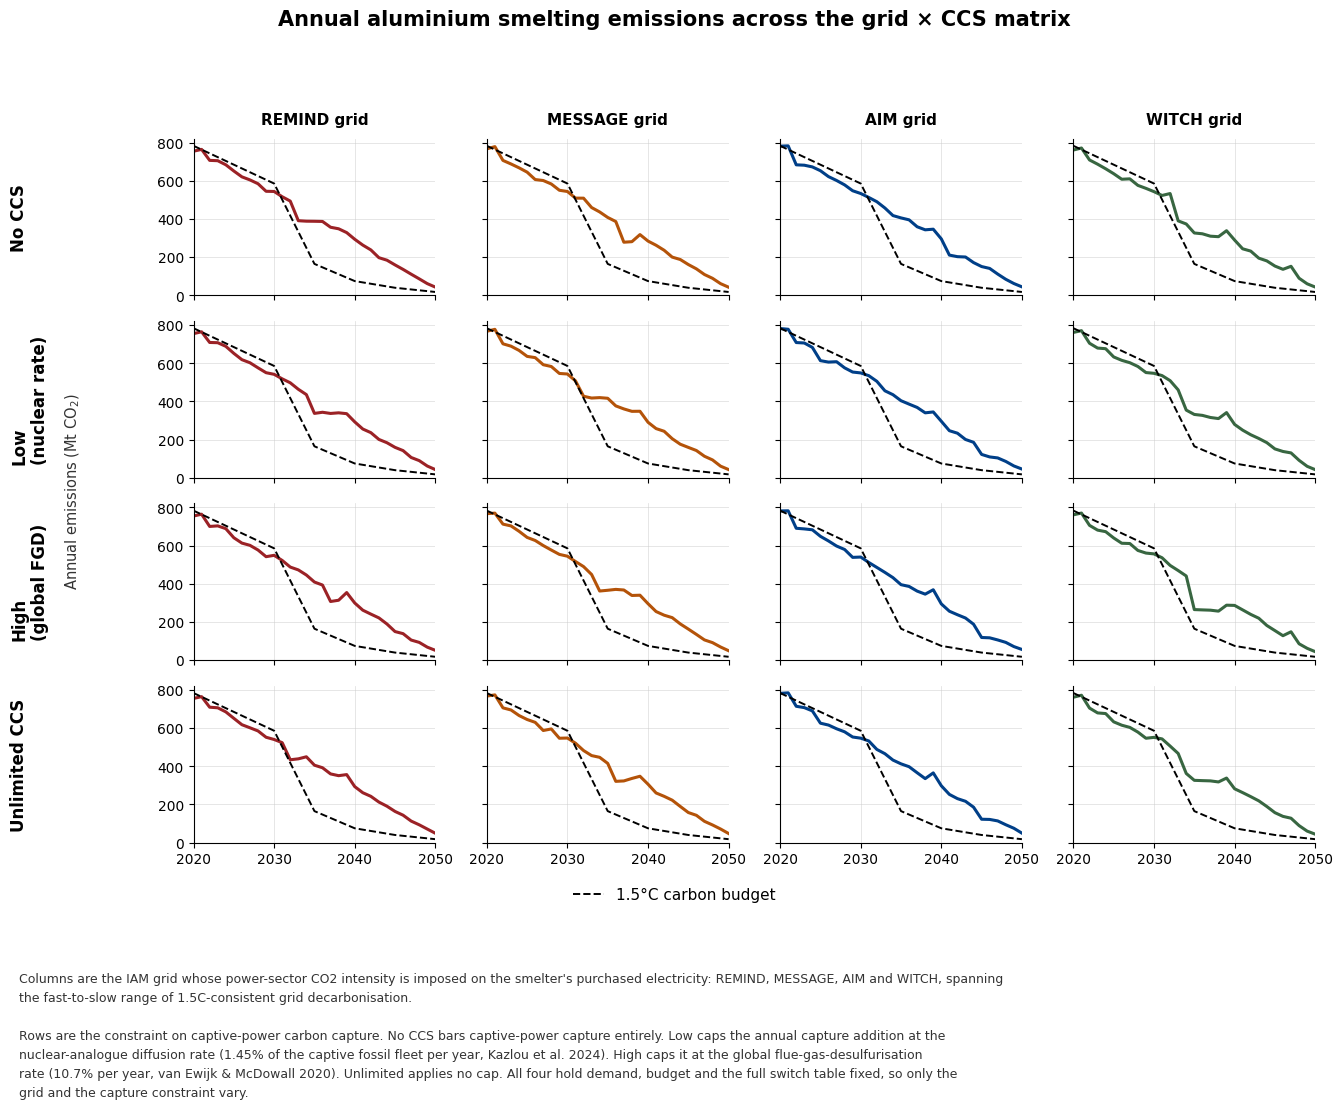

In [3]:
fig, axes = capture_grid(figsize=(13.5, 11.2))
for ccs in CCS_ORDER:
    for grid in GRIDS:
        ax = axes[(ccs, grid)]
        series = smelter[run_name(grid, ccs)]
        ax.plot(series.index, series.values, color=GRID_COLOURS[grid], lw=2.2,
                label="Scenario")
        ax.plot(limit.index, limit.values, "k--", lw=1.4, label="1.5\u00b0C carbon budget")
        ax.set_ylim(bottom=0)
handles, labels = axes[(CCS_ORDER[0], GRIDS[0])].get_legend_handles_labels()
fig.legend(handles[1:], labels[1:], loc="lower center", ncol=1, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, 0.175))
fig.suptitle("Annual aluminium smelting emissions across the grid \u00d7 CCS matrix",
             fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0.105, 0.205, 1, 0.94])
label_rows(axes, "Annual emissions (Mt CO$_2$)")
add_caption(fig, y=0.012)
save(fig, "smelting_emissions_annual")
plt.show()

## Cumulative emissions against the carbon budget

Shading is the overshoot.

wrote figures/smelting_emissions_cumulative.png and .svg


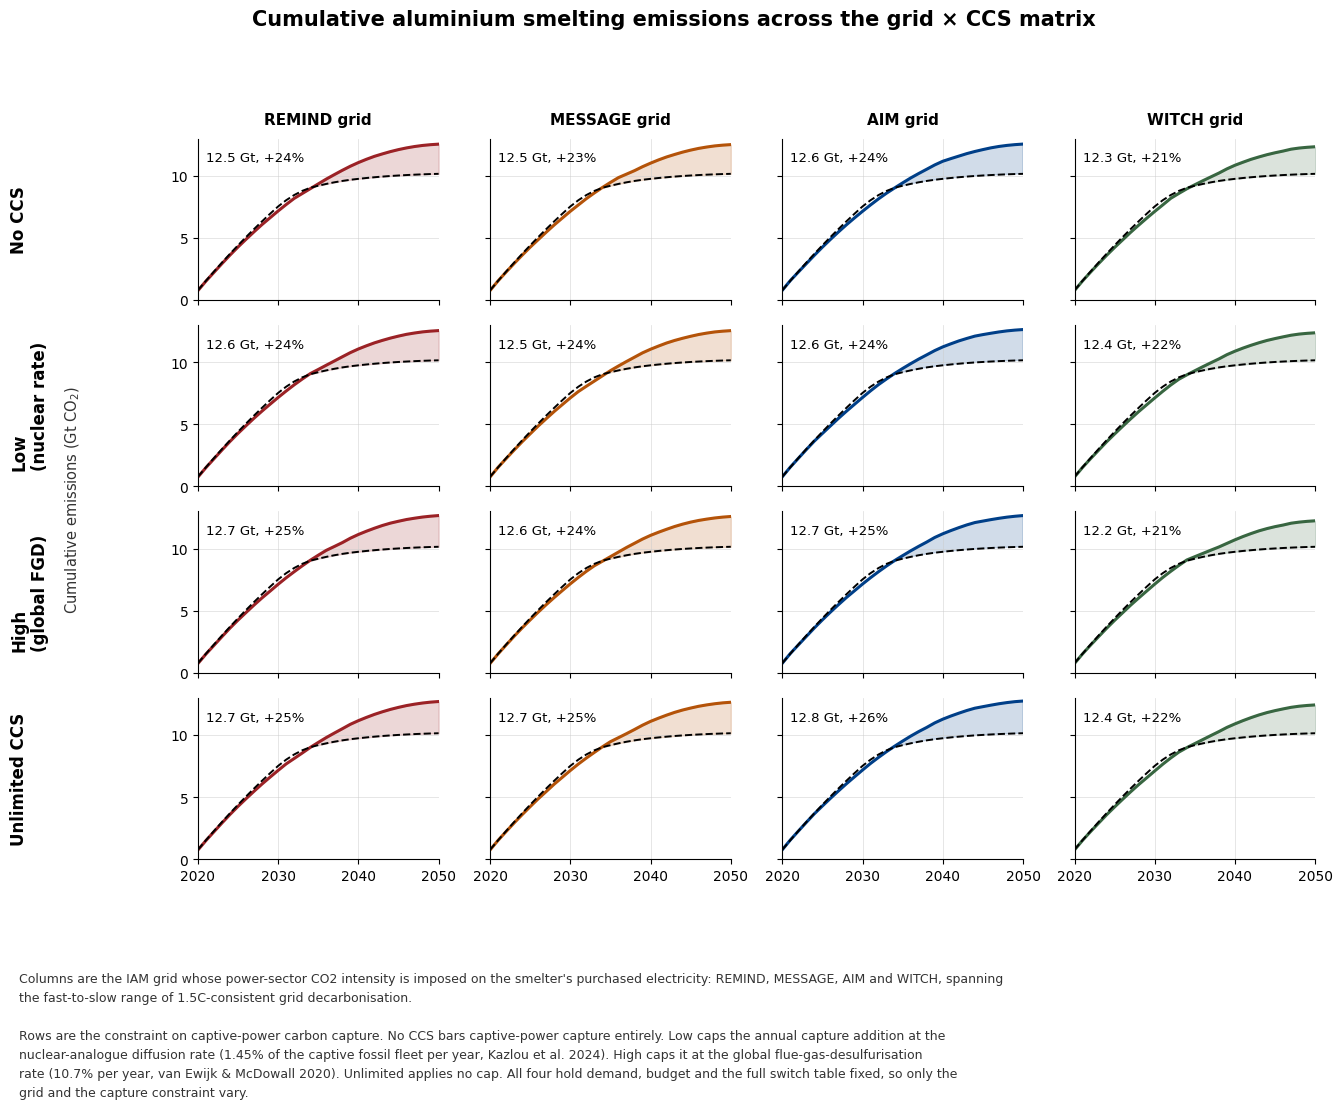

In [4]:
fig, axes = capture_grid(figsize=(13.5, 11.2))
for ccs in CCS_ORDER:
    for grid in GRIDS:
        ax = axes[(ccs, grid)]
        series = cumulative[run_name(grid, ccs)]
        ax.plot(series.index, series.values, color=GRID_COLOURS[grid], lw=2.2)
        ax.plot(budget_cum.index, budget_cum.values, "k--", lw=1.4)
        ax.fill_between(series.index, budget_cum.values, series.values,
                        where=series.values > budget_cum.values,
                        color=GRID_COLOURS[grid], alpha=0.18)
        over = 100 * (series.loc[2050] / budget_cum.loc[2050] - 1)
        ax.text(2021, 0.93 * 12, f"{series.loc[2050]:.1f} Gt, {over:+.0f}%", fontsize=9.5)
        ax.set_ylim(0, 13)
fig.suptitle("Cumulative aluminium smelting emissions across the grid \u00d7 CCS matrix",
             fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0.105, 0.19, 1, 0.94])
label_rows(axes, "Cumulative emissions (Gt CO$_2$)")
add_caption(fig, y=0.012)
save(fig, "smelting_emissions_cumulative")
plt.show()

## Summary

In [5]:
rows = []
for ccs in CCS_ORDER:
    for grid in GRIDS:
        n = run_name(grid, ccs)
        rows.append({"CCS regime": CCS_LABELS[ccs].replace("\n", " "), "Grid": grid,
                     "Smelting Gt": smelter[n].sum() / 1000,
                     "vs smelting budget %": 100 * (smelter[n].sum() / 1000 / budget_cum.loc[2050] - 1)})
pd.DataFrame(rows)

,CCS regime,Grid,Smelting Gt,vs smelting budget %
0,No CCS,REMIND,12.55,23.53
1,No CCS,MESSAGE,12.51,23.16
2,No CCS,AIM,12.55,23.58
3,No CCS,WITCH,12.34,21.46
4,Low (nuclear rate),REMIND,12.55,23.55
5,Low (nuclear rate),MESSAGE,12.55,23.51
6,Low (nuclear rate),AIM,12.63,24.38
7,Low (nuclear rate),WITCH,12.37,21.80
8,High (global FGD),REMIND,12.67,24.74
9,High (global FGD),MESSAGE,12.60,24.00
